In [1]:

import ml_pipelines.data.loader as loader
from config.settings import get_settings
from config.train_data import TrainDataConfig
from datasets import Dataset

from ml_pipelines.data.features import augment_data
from ml_pipelines.data.visualize import correlation_heatmap, graph_normal_distro
from ml_pipelines.data.data_source_cfg import all_data

data_cfg = TrainDataConfig()
settings = get_settings()


/Users/acg/Desktop/ML/text_grader/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#loads dataset from hf address specified in global cfg file
ds = loader.load_batch(
    all_data
)
#do the split
ds = loader.split_ds(ds)

Casting the dataset: 100%|██████████| 28662/28662 [00:00<00:00, 209937.87 examples/s]



Key: train, Length: 471272, Columns: ['text', 'label']
label stats:
mean: 0.4390
std:  0.4963
min:  0.0000
max:  1.0000

Key: test, Length: 58909, Columns: ['text', 'label']
label stats:
mean: 0.4380
std:  0.4962
min:  0.0000
max:  1.0000

Key: val, Length: 58909, Columns: ['text', 'label']
label stats:
mean: 0.4385
std:  0.4962
min:  0.0000
max:  1.0000


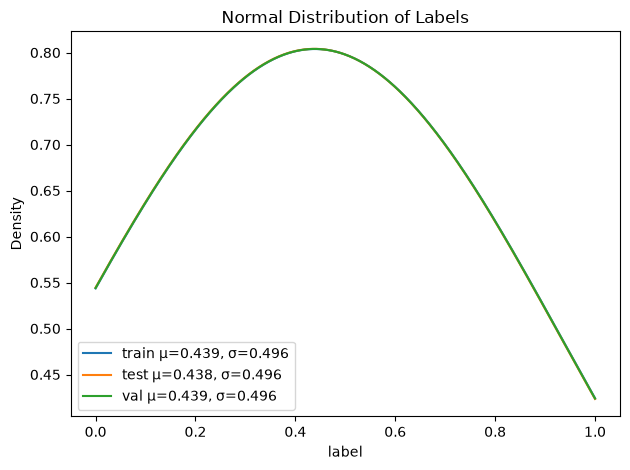

In [3]:
loader.print_ds_stats(ds)
graph_normal_distro(ds)

In [4]:

#augment the datasets with extra stats
ts = Dataset.to_polars(ds['test'])
tr = Dataset.to_polars(ds['train'])
val = Dataset.to_polars(ds['val'])
print(ts[1])

shape: (1, 2)
┌─────────────────────────────────┬───────┐
│ text                            ┆ label │
│ ---                             ┆ ---   │
│ str                             ┆ i64   │
╞═════════════════════════════════╪═══════╡
│ limiting car usage has a range… ┆ 1     │
└─────────────────────────────────┴───────┘


In [5]:
tr = augment_data(tr, data_cfg.text_column)
ts = augment_data(ts, data_cfg.text_column)
val = augment_data(val, data_cfg.text_column)
print(f"columns {ts.columns}")
print(f"tr shape = {tr.shape}, ts shape = {ts.shape}, val shape = {val.shape}")
print(ts[1])

columns ['text', 'label', 'num_sentences', 'num_words', 'num_chars', 'newline_count', 'avg_sent_len', 'sent_len_var', 'sent_len_std', 'sent_len_cv', 'max_sent_len', 'avg_word_len', 'word_len_var', 'word_len_std', 'max_word_len', 'unique_word_ratio', 'hapax_ratio', 'repeat_word_ratio', 'avg_word_repetition', 'comma_per_sent', 'semicolon_per_sent', 'em_dash_per_sent', 'parenthetical_per_sent', 'quotation_per_sent', 'punct_per_word', 'avg_adverbs_per_sent', 'word_len_entropy', 'sent_len_entropy']
tr shape = (471272, 28), ts shape = (58909, 28), val shape = (58909, 28)
shape: (1, 28)
┌────────────┬───────┬────────────┬───────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ text       ┆ label ┆ num_senten ┆ num_words ┆ … ┆ punct_per_ ┆ avg_adver ┆ word_len_ ┆ sent_len_ │
│ ---        ┆ ---   ┆ ces        ┆ ---       ┆   ┆ word       ┆ bs_per_se ┆ entropy   ┆ entropy   │
│ str        ┆ i64   ┆ ---        ┆ i64       ┆   ┆ ---        ┆ nt        ┆ ---       ┆ ---       │
│        

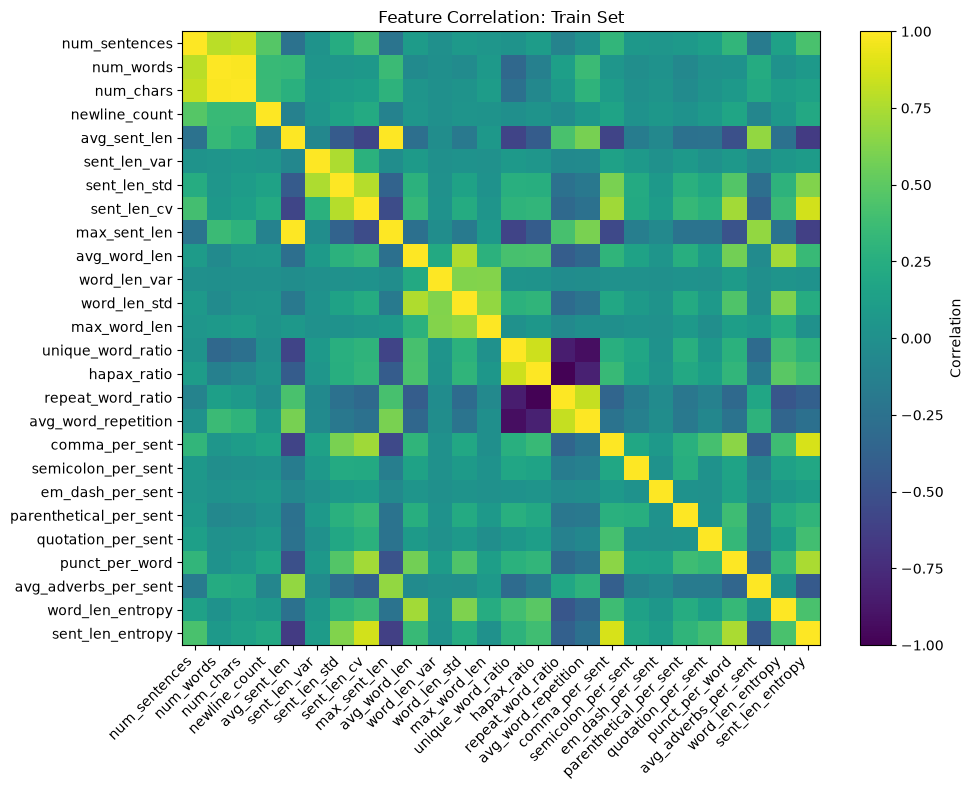

In [6]:

correlation_heatmap(tr, [data_cfg.text_column, data_cfg.target_column], "Feature Correlation: Train Set")

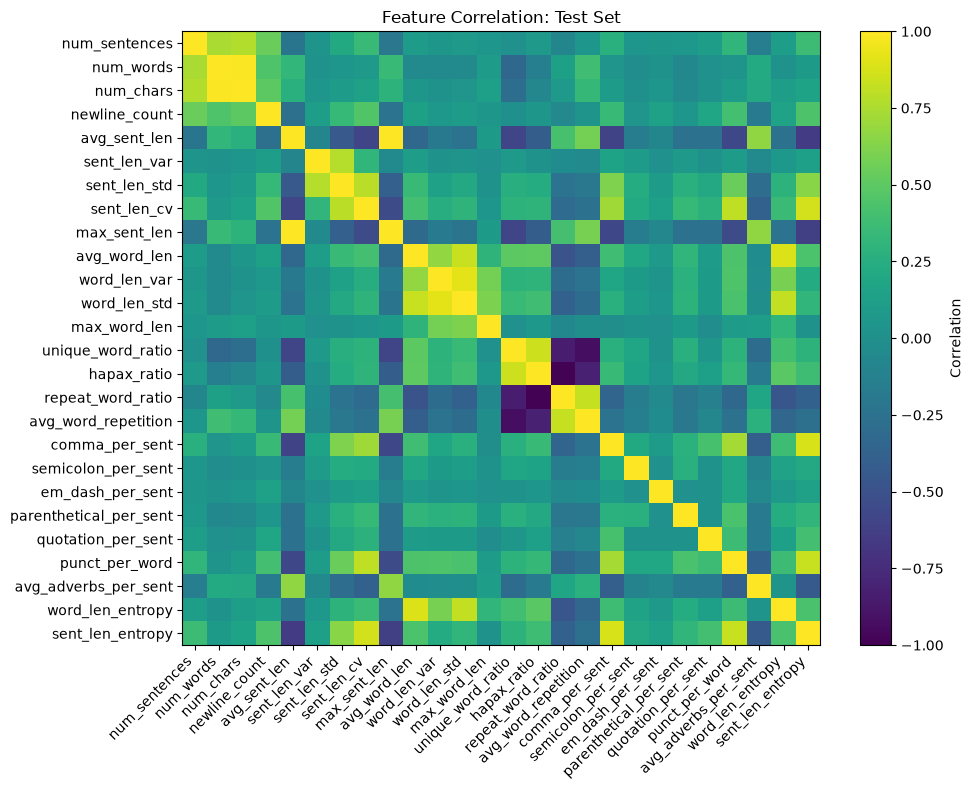

In [7]:
correlation_heatmap(ts, [data_cfg.text_column, data_cfg.target_column], "Feature Correlation: Test Set")


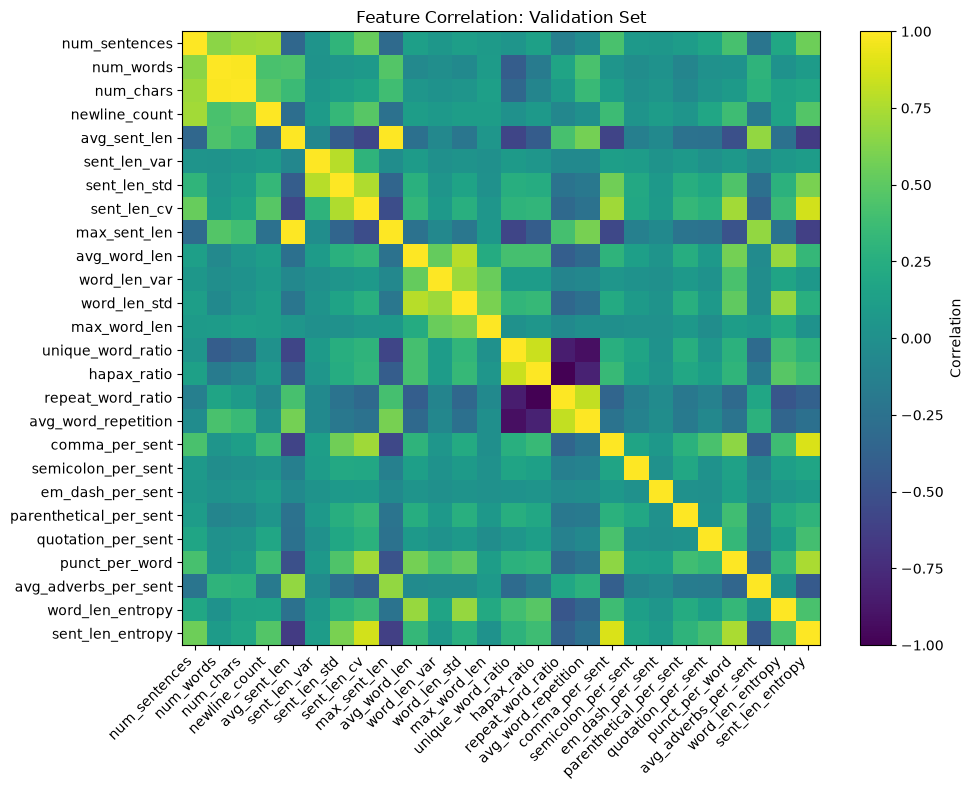

In [8]:
correlation_heatmap(val, [data_cfg.text_column, data_cfg.target_column], "Feature Correlation: Validation Set")


In [9]:
tr.write_csv(settings.io.train_path)
ts.write_csv(settings.io.test_path)
val.write_csv(settings.io.validation_path)

